# NOTEBOOK: DASHBOARD ANALÍTICO VTC

Descripción:
   Este notebook se conecta a la base de datos Postgres (Docker)
   y visualiza los insights analíticos del esquema "analytics".

   Está estructurado por categoría analítica:
   - Métricas de negocio
   - Conductores y operaciones
   - Usuarios y demanda
   - Análisis temporal y estacional
   - Insights geográficos
   - Análisis económico

## 1. Imports y conexión a la base de datos

In [30]:
import sys, os

# Añadir la carpeta raíz del proyecto al sys.path para poder trabajar desde el notebook
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from folium.plugins import HeatMap
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Las credenciales se leen del fichero .env de la raíz del proyecto,
# que no está versionado. Copia .env.example a .env si aún no lo has hecho.
load_dotenv(os.path.join(project_root, ".env"))

# El notebook se ejecuta fuera de Docker, así que la base de datos
# se alcanza por el puerto publicado en localhost.
os.environ["PG_HOST"] = "localhost"
print("Ejecutando en local, usando host=localhost")

warnings.filterwarnings("ignore")

Running locally, using host=localhost


In [33]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Conexión a PostgreSQL (Docker)
db_url = (
    f"postgresql+psycopg2://{os.environ['PG_USER']}:"
    f"{os.environ['PG_PASSWORD']}@"
    f"{os.getenv('PG_HOST', 'localhost')}:"
    f"{os.getenv('PG_PORT', 5432)}/"
    f"{os.environ['PG_DB']}"
)
engine = create_engine(db_url)
print("✅ Motor de SQLAlchemy creado correctamente")

# Función auxiliar para lanzar SQL y previsualizar el resultado
def query(sql: str) -> pd.DataFrame:
    df = pd.read_sql(sql, engine)
    print(f"Filas devueltas: {len(df)}")
    return df

✅ SQLAlchemy engine created successfully


## 2. MÉTRICAS DE NEGOCIO

### **Visión general del negocio:**
Aporta los KPIs globales: total de viajes, viajes válidos, ingresos totales (EUR), precio medio y duración de los viajes

In [41]:
business_overview = query("SELECT * FROM analytics.business_overview;")
display(business_overview)

Rows returned: 1


,total_trips,valid_trips,total_revenue_eur,avg_trip_price_eur,avg_effective_trip_duration_min,avg_waiting_time_min,revenue_per_minute_eur,num_countries
0,1860,1762,6821.82,3.87,19.92,6.54,0.18,7


**Ingresos por país:** Desglosa los ingresos totales (EUR), el número de viajes y el precio medio según el país del usuario

Rows returned: 7


,user_country,num_trips,total_revenue_eur,avg_trip_price_eur,avg_effective_trip_duration_min,revenue_per_minute_eur
0,ES,629,5473.49,8.70,19.50,0.45
1,PE,217,670.16,3.09,19.17,0.16
2,EC,166,379.92,2.29,18.13,0.13
3,MX,83,227.20,2.74,20.39,0.13
4,AR,117,55.13,0.47,20.77,0.02
5,CL,184,9.06,0.05,21.24,0.00
6,CO,366,6.86,0.02,18.14,0.00


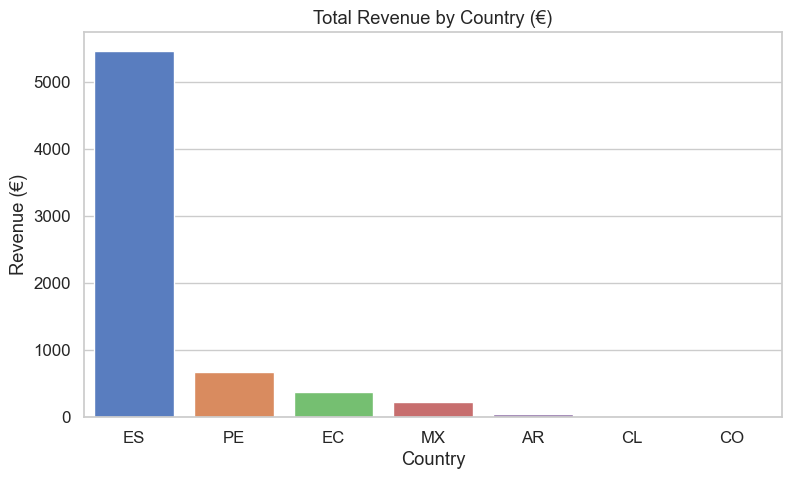

In [35]:
revenue_by_country = query("SELECT * FROM analytics.revenue_by_country;")
display(revenue_by_country)


plt.figure(figsize=(9,5))
sns.barplot(x="user_country", y="total_revenue_eur", data=revenue_by_country, hue="user_country", legend=False)
plt.title("Ingresos totales por país (€)")
plt.xlabel("País")
plt.ylabel("Ingresos (€)")
plt.show()

### **Ingresos en el tiempo:**
Muestra la evolución diaria de los ingresos totales

Rows returned: 35


,trip_year,trip_month,trip_date,num_trips,total_revenue_eur,avg_trip_price_eur,aggregation_level
0,2021-01-01,2021-09-01,2021-09-01,12,8.13,0.68,daily
1,2021-01-01,2021-09-01,2021-09-02,51,194.52,3.81,daily
2,2021-01-01,2021-09-01,2021-09-03,52,145.80,2.80,daily
3,2021-01-01,2021-09-01,2021-09-04,51,161.29,3.16,daily
4,2021-01-01,2021-09-01,2021-09-05,58,255.05,4.40,daily


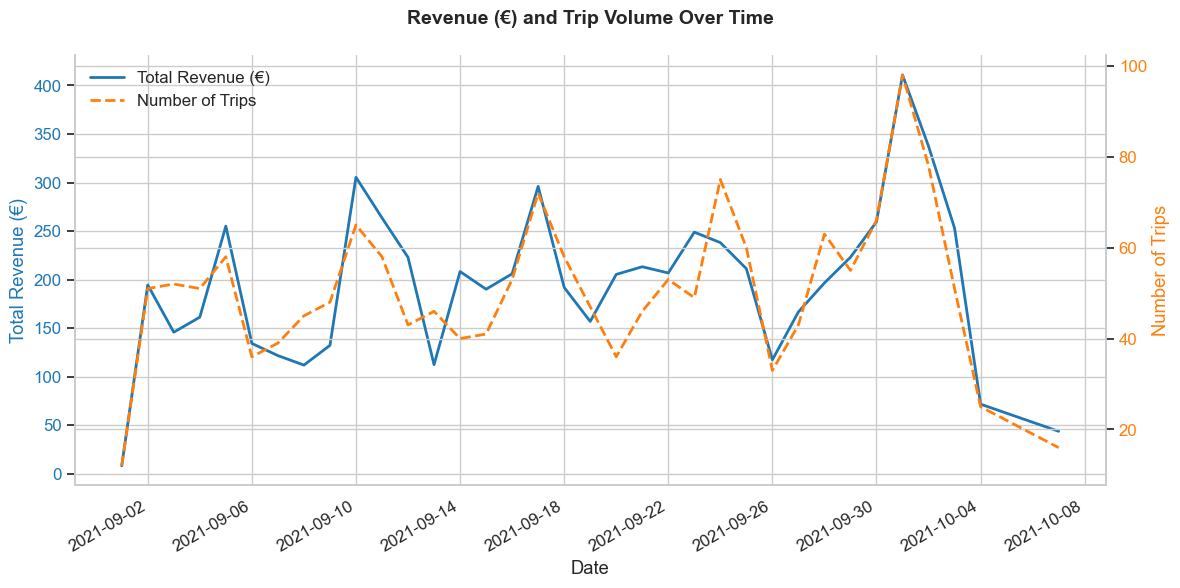

In [36]:
revenue_over_time = query("SELECT * FROM analytics.revenue_over_time WHERE aggregation_level = 'daily';")
display(revenue_over_time.head(5))

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = "tab:blue"
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Ingresos totales (€)", color=color1)
ax1.plot(
    revenue_over_time["trip_date"],
    revenue_over_time["total_revenue_eur"],
    color=color1,
    linewidth=2,
    label="Ingresos totales (€)"
)
ax1.tick_params(axis="y", labelcolor=color1)

# Segundo eje para el número de viajes
ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.set_ylabel("Número de viajes", color=color2)
ax2.plot(
    revenue_over_time["trip_date"],
    revenue_over_time["num_trips"],
    color=color2,
    linewidth=2,
    linestyle="--",
    label="Número de viajes"
)
ax2.tick_params(axis="y", labelcolor=color2)

# Formatear el eje X para evitar solapamientos
fig.autofmt_xdate(rotation=30)
ax1.xaxis.set_major_locator(plt.MaxNLocator(10))  # limita el número de marcas de fecha

# Título y leyenda combinada
fig.suptitle("Ingresos (€) y volumen de viajes en el tiempo", fontsize=14, fontweight="bold")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left", frameon=False)

sns.despine(right=False)
plt.tight_layout()
plt.show()

## 3. CONDUCTORES Y OPERACIONES

### **Rendimiento de los conductores:**
Mide la productividad de los conductores: viajes, ingresos totales y medios, y duración media por conductor

Rows returned: 1411


,driver_id,driver_state,num_trips,total_revenue_eur,avg_trip_price_eur,avg_effective_trip_duration_min,revenue_per_minute_eur
0,1B2M2Y8AsgTpgAmY7PhCfg==,None,252,0.00,0.00,8.90,0.00
1,OpNqA2r4Aw3zi5OZ+jYL0w==,NaN,3,0.00,0.00,2.12,0.00
2,zvmlOXz4CBbaP79Z71OWIg==,NaN,3,19.90,6.63,33.17,0.20
3,3t3DI+zy5R846qzvmzuNGQ==,NaN,3,33.06,11.02,15.58,0.71
4,Y460chy64sUGnMYuMRkvlA==,NaN,3,29.38,9.79,15.89,0.62


Rows returned: 4


,num_trips,n_trips
0,3,5
1,252,1
2,2,90
3,1,1315


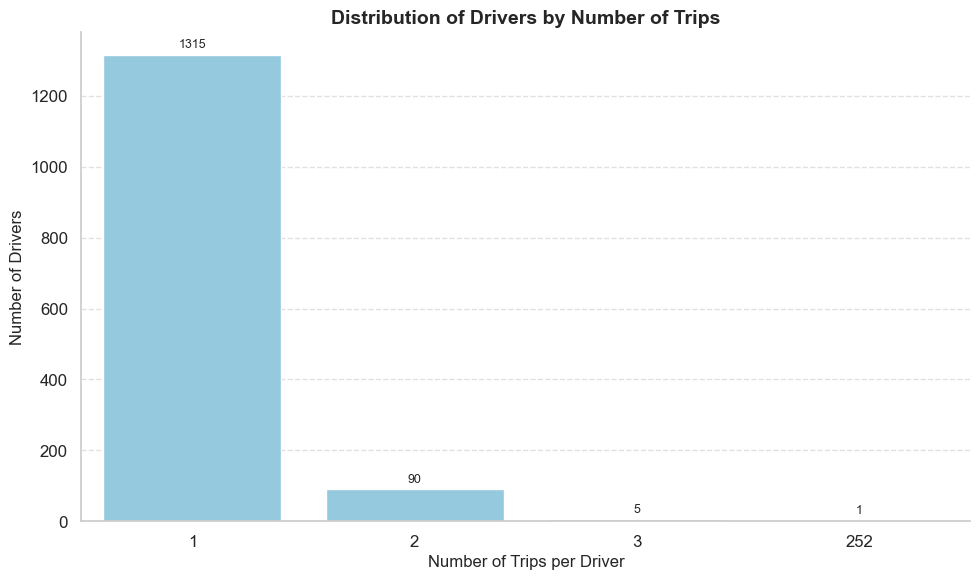

In [37]:
driver_perf = query("SELECT * FROM analytics.driver_performance ORDER BY num_trips DESC;")
display(driver_perf.head(5))

n_trips_per_driver = query("SELECT num_trips, COUNT(*) AS n_trips FROM analytics.driver_performance GROUP BY num_trips;")
display(n_trips_per_driver.head(5))

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x="num_trips",
    y="n_trips",
    data=n_trips_per_driver,
    color="skyblue"
)

# Etiquetas
plt.title("Distribución de conductores por número de viajes", fontsize=14, fontweight="bold")
plt.xlabel("Número de viajes por conductor", fontsize=12)
plt.ylabel("Número de conductores", fontsize=12)

# Mostrar los valores encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9, padding=3)

# Mejoras de visualización
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()


1315 conductores hicieron 1 viaje, 90 conductores hicieron 2 viajes y 5 conductores hicieron 3 viajes. Nota: el único conductor con 252 viajes no es un conductor real (no aparece en la tabla `drivers`), sino el *placeholder* mencionado en el análisis exploratorio (con ID `1B2M2Y8AsgTpgAmY7PhCfg==`), que hace de «estado de espera» del sistema. Por tanto, no debería tenerse en cuenta al interpretar este gráfico.

### **Resumen de cambios de conductor:**
Muestra el número medio, mínimo y máximo de cambios de conductor por viaje

In [38]:
driver_changes = query("SELECT * FROM analytics.driver_changes_summary;")
display(driver_changes)

Rows returned: 1


,avg_driver_changes,min_driver_changes,max_driver_changes
0,1.9,1,8


## 4. USUARIOS Y DEMANDA

### **Distribución de usuarios:**
Distribución de los usuarios por país: media de viajes y de gasto por usuario

Rows returned: 7


,locale_country,num_users,avg_trips_per_user,avg_spent_per_user_eur
0,ES,42,14.98,130.32
1,CO,18,20.33,0.38
2,PE,12,18.08,55.85
3,EC,9,18.44,42.21
4,CL,9,20.44,1.01
5,AR,7,16.71,7.88
6,MX,2,41.50,113.60


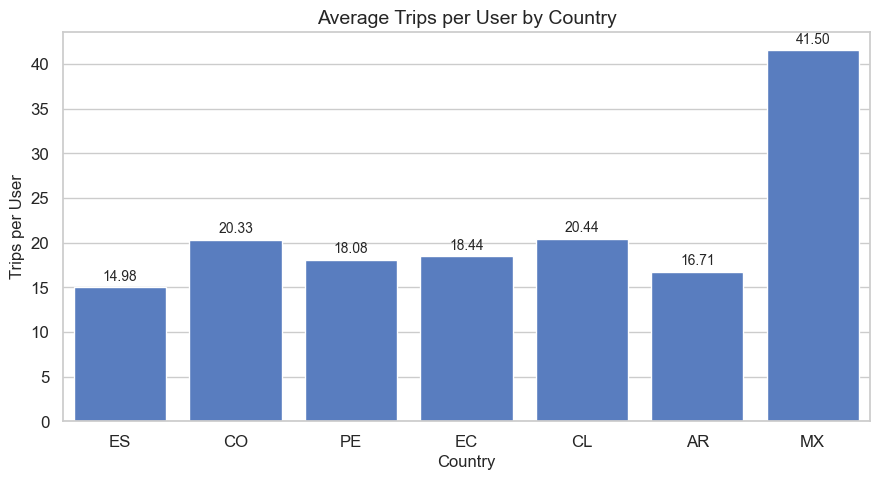

In [39]:
user_dist = query("SELECT * FROM analytics.user_distribution;")
display(user_dist)


plt.figure(figsize=(9,5))
ax = sns.barplot(x="locale_country", y="avg_trips_per_user", data=user_dist)

# Título y etiquetas
plt.title("Media de viajes por usuario y país", fontsize=14)
plt.xlabel("País", fontsize=12)
plt.ylabel("Viajes por usuario", fontsize=12)

# Añadir los valores encima de las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

## 5. ANÁLISIS TEMPORAL Y ESTACIONAL

### **Viajes por hora:**
Número de viajes y precio medio agrupados por hora del día

Rows returned: 24


,start_hour,num_trips,avg_price_eur,avg_effective_trip_duration_min,avg_waiting_time_min
0,0,49,4.00,14.65,1.37
1,1,40,4.99,16.17,0.55
2,2,41,6.62,23.34,1.40
3,3,23,8.08,16.70,32.46
4,4,33,3.92,13.27,1.24


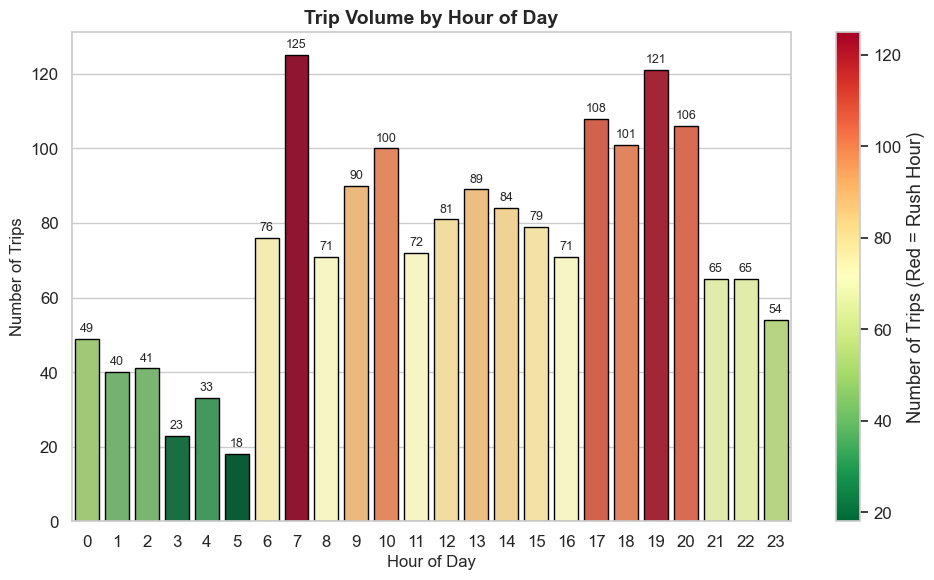

In [40]:
trips_by_hour = query("SELECT * FROM analytics.trips_by_hour;")
display(trips_by_hour.head(5))


norm = plt.Normalize(trips_by_hour["num_trips"].min(), trips_by_hour["num_trips"].max())
colors = plt.cm.RdYlGn_r(norm(trips_by_hour["num_trips"]))

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x="start_hour",
    y="num_trips",
    data=trips_by_hour,
    palette=colors,
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9, padding=3)

plt.title("Volumen de viajes por hora del día", fontsize=14, weight='bold')
plt.xlabel("Hora del día", fontsize=12)
plt.ylabel("Número de viajes", fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Número de viajes (rojo = hora punta)")

plt.show()

Nota: como ya se ha comentado, las horas de los viajes en el `dataset.zip` original venían en UTC. Sin embargo, para poder saber realmente cuáles son las horas punta, los datos deben transformarse y normalizarse según el país.

Rows returned: 1844


,trip_id,created_at,updated_at,start_at,week_day,start_day,start_date,start_month,start_year,start_hour,...,end_lon,trip_duration_minutes,effective_trip_duration_minutes,waiting_time_minutes,price,exchange_rate,price_eur,user_country,driver_state,car_type
0,DQS71JVE3boZXMTZEzmOzg==,2021-09-07 08:22:26.480,2021-09-07 08:45:56.743,2021-09-07 08:22:22.525,2,2021-09-07,7,9,2021,8,...,-3.619056,23.504383,23.402933,0.101450,1486.0,1.000,14.86,ES,NaN,None
1,DoglnrOieUzkaTVfeKps4w==,2021-09-26 19:25:33.143,2021-09-26 20:01:13.667,2021-09-26 19:25:30.744,7,2021-09-26,26,9,2021,19,...,-99.125900,35.675400,24.932733,10.742667,8979.0,0.051,4.58,MX,orjtnDBbjqhhFrYDzKeKlw==,None
2,6Q9LlxWw3fpFNq76T1u50w==,2021-09-04 09:56:58.687,2021-09-04 10:29:02.824,2021-09-04 09:56:56.595,6,2021-09-04,4,9,2021,9,...,-99.172433,32.068950,30.501450,1.567500,4892.0,0.051,2.49,MX,orjtnDBbjqhhFrYDzKeKlw==,None
3,23UTDK0cbmFOmJ06FdKpNw==,2021-09-04 12:41:04.021,2021-09-04 13:06:01.143,2021-09-04 12:41:00.718,6,2021-09-04,4,9,2021,12,...,-70.521198,24.952033,10.210783,14.741250,1100.0,0.001,0.01,CL,NaN,None
4,nAf+oh1LIhnCjxrBFADaWA==,2021-09-29 10:08:41.285,2021-09-29 10:24:03.945,2021-09-29 10:08:38.434,3,2021-09-29,29,9,2021,10,...,-0.374506,15.377667,15.285033,0.092633,900.0,1.000,9.00,ES,NaN,None


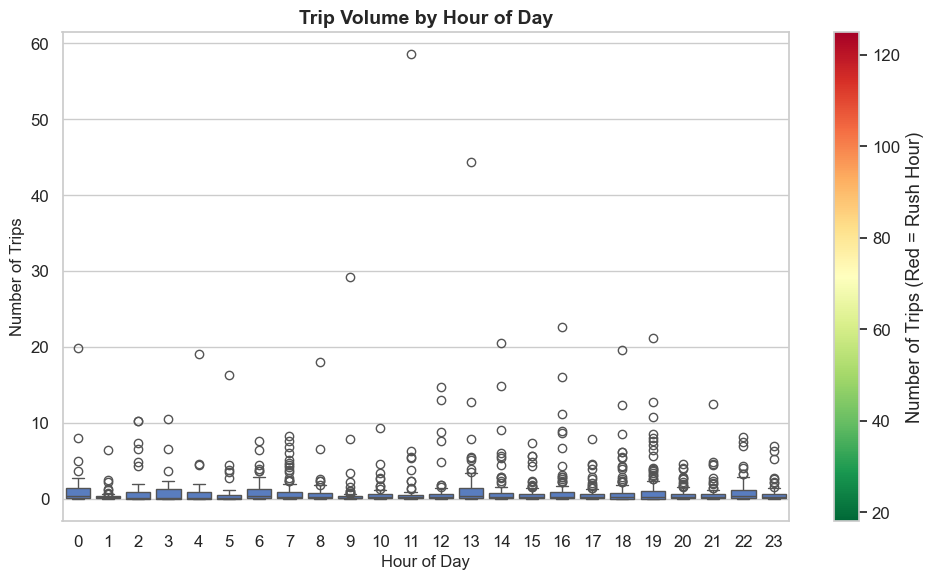

In [42]:
trips_by_hour = query("SELECT *  FROM analytics.trips_with_reason WHERE waiting_time_minutes < 60;")
display(trips_by_hour.head(5))


plt.figure(figsize=(10,6))
ax = sns.boxplot(
    x="start_hour",
    y="waiting_time_minutes",
    data=trips_by_hour
)

plt.title("Volumen de viajes por hora del día", fontsize=14, weight='bold')
plt.xlabel("Hora del día", fontsize=12)
plt.ylabel("Número de viajes", fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Número de viajes (rojo = hora punta)")

plt.show()

Ahora vamos a tener en cuenta únicamente los viajes con `waiting_time_minutes > 60`, es decir, los que consideramos reservas. Vamos a investigar si hay alguna franja horaria concreta con más reservas:

In [43]:
n_reservations = query("SELECT start_hour, COUNT(*) as n_reservations FROM analytics.trips_with_reason WHERE waiting_time_minutes > 60 GROUP BY start_hour;")
display(n_reservations)

Rows returned: 9


,start_hour,n_reservations
0,3,1
1,6,4
2,7,4
3,8,2
4,10,1
5,14,1
6,15,1
7,19,1
8,22,1


Efectivamente, la mayoría de las reservas (viajes con `waiting_time_minutes > 60`, 12 de 16) se concentran en la madrugada y primera hora de la mañana (de 3:00 a 8:00).

### **Viajes por día de la semana:**
Viajes y precios medios por día de la semana

Rows returned: 7


,weekday,weekday_number,num_trips,avg_price_eur,avg_effective_trip_duration_min,avg_waiting_time_min
0,Monday,1,186,3.71,19.41,13.67
1,Tuesday,2,188,3.94,18.25,7.44
2,Wednesday,3,206,3.59,22.00,8.50
3,Thursday,4,283,3.83,20.85,6.55
4,Friday,5,362,3.86,19.54,4.99
5,Saturday,6,305,3.82,17.41,6.84
6,Sunday,7,232,4.33,18.31,3.07


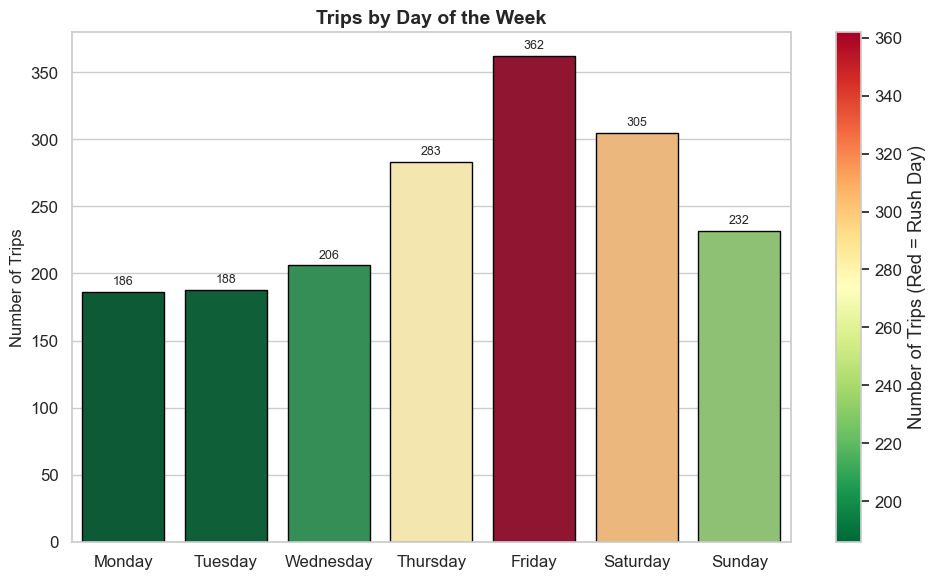

In [44]:
trips_by_weekday = query("SELECT * FROM analytics.trips_by_weekday;")
display(trips_by_weekday)


norm = plt.Normalize(trips_by_weekday["num_trips"].min(), trips_by_weekday["num_trips"].max())
colors = plt.cm.RdYlGn_r(norm(trips_by_weekday["num_trips"])) 

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x="weekday",
    y="num_trips",
    data=trips_by_weekday,
    palette=colors,
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9, padding=3)

plt.title("Viajes por día de la semana", fontsize=14, weight='bold')
plt.xlabel("", fontsize=12)
plt.ylabel("Número de viajes", fontsize=12)
plt.xticks(range(0, 7))
plt.tight_layout()

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Número de viajes (rojo = día punta)")

plt.show()

Se aprecia que los días más tranquilos están al principio de la semana y que hay picos de demanda los viernes y los sábados.

### Duración efectiva del viaje

Rows returned: 5


,duration_bucket,num_trips,avg_price_eur
0,20-40 min,565,6.94
1,10-20 min,563,3.59
2,<5 min,384,0.00
3,40+ min,125,6.03
4,5-10 min,125,1.03


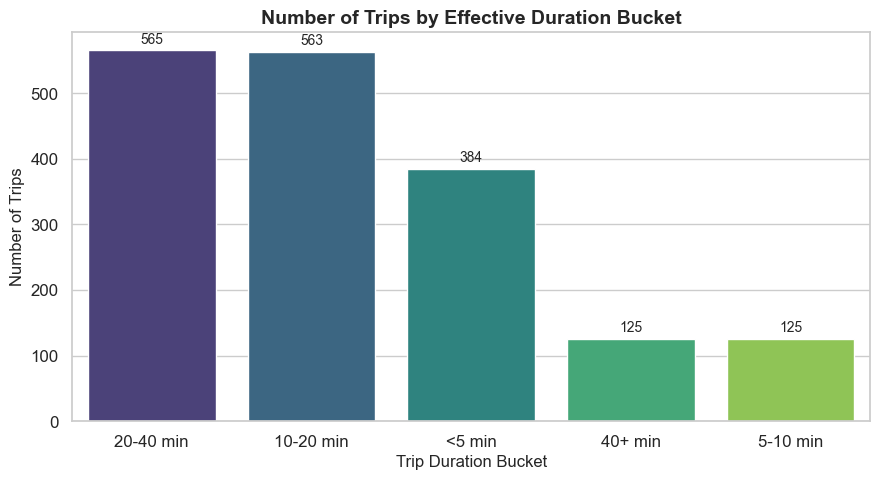

In [45]:
effective_dist = query("SELECT * FROM analytics.effective_duration_distribution;")
display(effective_dist)

# Ordenar los datos por número de viajes de forma descendente
effective_dist = effective_dist.sort_values(by="num_trips", ascending=False)

plt.figure(figsize=(9,5))
ax = sns.barplot(
    x="duration_bucket",
    y="num_trips",
    data=effective_dist,
    palette="viridis"
)

# Título y etiquetas
plt.title("Número de viajes por tramo de duración efectiva", fontsize=14, weight="bold")
plt.xlabel("Tramo de duración del viaje", fontsize=12)
plt.ylabel("Número de viajes", fontsize=12)

# Valores encima de las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3)

plt.tight_layout()
plt.show()


## 6. INSIGHTS GEOGRÁFICOS

### **Rutas principales por país:**
Las rutas de cada país en las que hubo al menos dos viajes. Se guarda un fichero HTML (en `notebooks/outputs`) con un mapa interactivo que permite hacer zoom y ver las rutas con más tráfico de cada zona. Al pasar el ratón por encima del trazado también se indican el tiempo medio de espera y el tiempo medio de trayecto.

In [46]:
routes = query("SELECT * FROM analytics.top_routes_by_country;")
display(routes)

Rows returned: 133


,user_country,start_lat,start_lon,end_lat,end_lon,num_trips,avg_effective_trip_duration_min,avg_waiting_time_min,route_rank
0,AR,-34.58,-58.45,-34.55,-58.45,7,21.32,0.27,1
1,AR,-34.55,-58.45,-34.58,-58.45,4,20.98,0.84,2
2,AR,-34.57,-58.44,-34.58,-58.42,4,6.95,0.91,3
3,AR,-34.59,-58.44,-34.59,-58.42,3,16.16,0.66,4
4,AR,-34.58,-58.45,-34.59,-58.43,3,11.16,0.73,5
...,...,...,...,...,...,...,...,...,...
128,PE,-12.13,-76.99,-12.13,-77.03,3,26.53,0.43,15
129,PE,-12.10,-77.02,-12.11,-76.96,2,7.13,0.16,16
130,PE,-12.10,-77.04,-12.08,-76.94,2,15.38,0.54,17
131,PE,-12.11,-77.00,-12.09,-77.01,2,9.68,0.29,18


In [48]:
# Crear el directorio outputs/ si no existe
os.makedirs("outputs", exist_ok=True)

In [49]:
# Normalizar los valores
norm = plt.Normalize(routes["num_trips"].min(), routes["num_trips"].max())
cmap = plt.cm.RdYlGn_r  # rojo = más viajes, verde = menos viajes

# Crear el mapa base
m_routes = folium.Map(
    location=[routes["start_lat"].mean(), routes["start_lon"].mean()],
    zoom_start=4, tiles="cartodb positron"
)

# Dibujar las rutas coloreadas según num_trips
for _, row in routes.iterrows():
    color = mcolors.to_hex(cmap(norm(row["num_trips"])))
    folium.PolyLine(
        locations=[(row["start_lat"], row["start_lon"]), (row["end_lat"], row["end_lon"])],
        color=color,
        weight=row["num_trips"] * 2,
        opacity=1,
        tooltip=f"{row['user_country']} | {row['num_trips']} viajes | puesto {row['route_rank']} | {row['avg_effective_trip_duration_min']} min de viaje | {row['avg_waiting_time_min']} min de espera"
    ).add_to(m_routes)

m_routes.save("outputs/top_routes_by_intensity.html")
print("✅ Mapa guardado con una escala de color según la intensidad de viajes.")


✅ Map saved with a color scale according to trip intensity.


### **Hotspots de inicio y de fin:**
Puntos de inicio y de fin de viaje más frecuentes por país. Se generan 3 ficheros HTML:
- **hotspots_start_end:** mapa de burbujas donde los puntos azules indican los puntos de partida y los rojos los de llegada. Cuantas más veces se ha usado una coordenada como inicio o como fin, mayor es el tamaño del círculo.
- **hotspots_start_heatmap:** mapa de calor que muestra las zonas donde se origina el mayor número de viajes.
- **hotspots_end_heatmap:** mapa de calor que muestra las zonas donde finalizan más viajes.


Mapa de calor:

In [50]:
hotspots_start = query("SELECT * FROM analytics.hotspots_start;")
hotspots_end = query("SELECT * FROM analytics.hotspots_end;")
display(hotspots_start.head(5))


# Crear el mapa centrado
center_lat = hotspots_start["lat"].mean()
center_lon = hotspots_start["lon"].mean()
m_hotspots = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles="cartodb positron")

# Puntos de inicio (azul)
for _, row in hotspots_start.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["num_trips"],
        color="blue",
        fill=True,
        fill_opacity=1,
        popup=f"Inicio | {row['user_country']} | {row['num_trips']} viajes"
    ).add_to(m_hotspots)

# Puntos de fin (rojo)
for _, row in hotspots_end.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["num_trips"],
        color="red",
        fill=True,
        fill_opacity=1,
        popup=f"Fin | {row['user_country']} | {row['num_trips']} viajes"
    ).add_to(m_hotspots)

# Guardar el mapa
m_hotspots.save("outputs/hotspots_start_end.html")

Rows returned: 747
Rows returned: 789


,user_country,lat,lon,num_trips
0,EC,-2.162,-79.907,33
1,MX,19.345,-99.172,25
2,CO,4.693,-74.054,20
3,CL,-33.415,-70.518,20
4,ES,41.414,2.222,18


Mapa de las coordenadas de inicio:

In [52]:
heat_data = hotspots_start[["lat", "lon", "num_trips"]].dropna().values.tolist()

m_heat = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles="cartodb positron")

HeatMap(
    data=heat_data,
    radius=12,         
    blur=15,         
    max_zoom=6,
    min_opacity=1,
).add_to(m_heat)

# Guardar el mapa
m_heat.save("outputs/hotspots_start_heatmap.html")

Mapa de las coordenadas de fin:

In [51]:
heat_data = hotspots_end[["lat", "lon", "num_trips"]].dropna().values.tolist()

m_heat = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles="cartodb positron")

HeatMap(
    data=heat_data,
    radius=12,         
    blur=15,           
    max_zoom=6,
    min_opacity=1,
).add_to(m_heat)

# Guardar el mapa
m_heat.save("outputs/hotspots_end_heatmap.html")

## 7. ANÁLISIS ECONÓMICO

### **Distribución de precios:**
Resume el número de viajes y las estadísticas de precio (media, mediana, mínimo y máximo) por país

Rows returned: 7


,user_country,total_trips,trips_with_price,trips_with_price_zero,trips_with_price_positive,avg_price_eur,min_price_eur,max_price_eur,median_price_eur,stddev_price_eur
0,ES,668,629,167,462,11.85,3.37,50.08,9.34,7.80
1,CO,383,366,146,220,0.03,0.01,0.18,0.03,0.02
2,PE,225,217,39,178,3.76,1.38,16.10,3.12,2.14
3,CL,201,184,40,144,0.06,0.01,0.27,0.05,0.04
4,EC,177,166,40,126,3.02,1.30,22.11,2.41,2.12
5,AR,119,117,14,103,0.54,0.21,1.80,0.45,0.31
6,MX,87,83,38,45,5.05,2.09,11.98,4.45,3.05


Rows returned: 1282


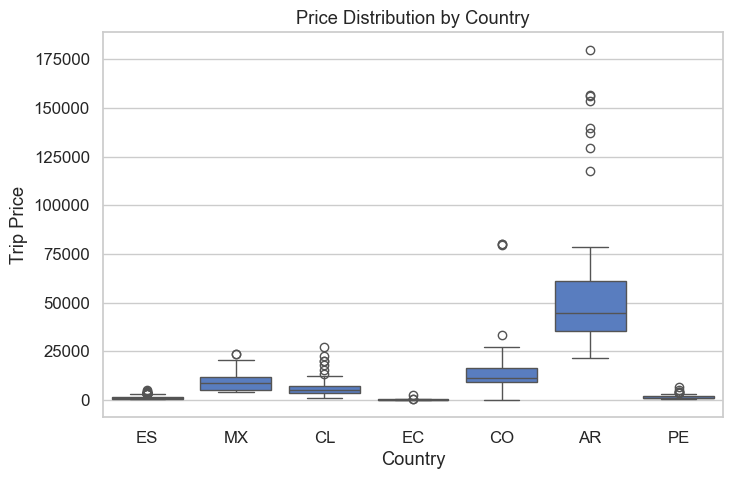

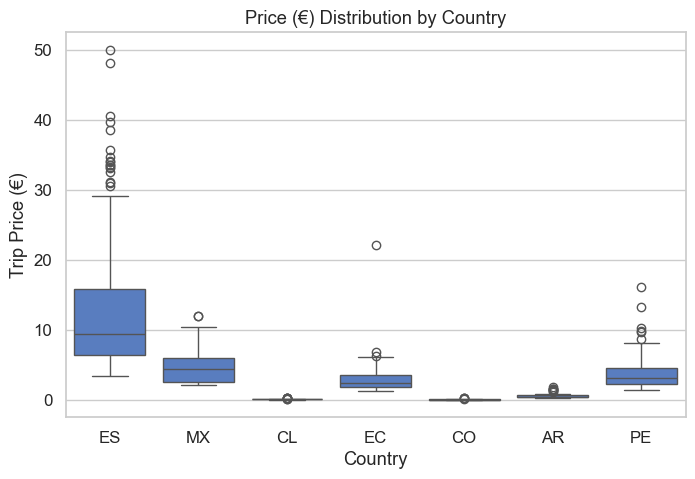

In [53]:
price_dist = query("SELECT * FROM analytics.price_distribution;")
display(price_dist)

prices = query("SELECT * FROM core.fact__trips WHERE reason IS NOT NULL AND price <> 'NaN' AND price > 0;")

plt.figure(figsize=(8,5))
sns.boxplot(x="user_country", y="price", data=prices)
plt.title("Distribución de precios por país")
plt.xlabel("País")
plt.ylabel("Precio del viaje")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="user_country", y="price_eur", data=prices)
plt.title("Distribución de precios (€) por país")
plt.xlabel("País")
plt.ylabel("Precio del viaje (€)")
plt.show()

Convertir todos los precios de los viajes a una divisa común (€) proporciona una medida estandarizada y comparable entre países.

Como se ve en el primer boxplot, los precios en divisa local varían enormemente por las diferencias de tipo de cambio y la dinámica de cada mercado local, lo que hace que las comparaciones directas carezcan de sentido.

Sin embargo, una vez convertidos los precios a euros (segundo boxplot), los valores quedan normalizados y son analíticamente consistentes, lo que permite comparar de forma justa el comportamiento de los precios, el coste de los viajes y los patrones de gasto de los usuarios en todos los mercados.

Dicho esto, la conversión por tipo de cambio por sí sola no tiene en cuenta la inflación, las diferencias de poder adquisitivo ni el coste de la vida local, factores que pueden seguir afectando a la comparabilidad de los precios entre países y que conviene considerar para un análisis más preciso y contextualizado.